# 03 — Classification Models

Demonstrates the classification side of the ML Starter Kit: comparing several classifiers,
tuning the winner, and visualizing results with the confusion matrix and ROC curve helpers
from `src.utils.visualization`.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_data
from src.data.splitter import split_data
from src.preprocessing.pipeline import build_preprocessor, build_pipeline
from src.models.factory import get_model
from src.evaluation.metrics import evaluate_model
from src.evaluation.model_selection import compare_models, tune_model
from src.evaluation.importance import get_feature_names, tree_feature_importance
from src.utils.visualization import plot_confusion_matrix, plot_roc_curve, plot_feature_importance

## Load data and split

In [2]:
df = load_data("../data/raw/customer_churn.csv")

[07:09:42] INFO     src.data.loader: Loaded 'customer_churn.csv' as csv -> shape=(600, 8)


DATA SUMMARY
Rows: 600   Columns: 8
Duplicate rows: 0

Dtypes:
int64      3
float64    3
object     2

Missing values (columns with at least one):
income    60
age       30
city      18


In [3]:
X_train, X_test, y_train, y_test = split_data(
    df.drop(columns=["customer_id"]), target="churn",
    test_size=0.2, random_state=42, stratify=True,
)
numerical_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
preprocessor = build_preprocessor(numerical_features, categorical_features)

[07:09:42] INFO     src.data.splitter: Split data: train=(480, 6), test=(120, 6), stratified=True


[07:09:42] INFO     src.preprocessing.pipeline: Built preprocessor: 4 numeric, 2 categorical columns


## Compare several classifiers

In [4]:
comparison_df = compare_models(
    model_names=["logistic", "decision_tree_classifier", "random_forest_classifier",
                 "gradient_boosting_classifier", "knn"],
    preprocessor=preprocessor,
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
    cv=5, scoring="roc_auc", stratified=True,
)
comparison_df

[07:09:42] INFO     src.models.factory: Created model: logistic -> LogisticRegression({})


[07:09:42] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=roc_auc): mean=0.7439, std=0.0063


[07:09:42] INFO     src.evaluation.model_selection: compare_models -- logistic: CV=0.7439, Test=0.6651


[07:09:42] INFO     src.models.factory: Created model: decision_tree_classifier -> DecisionTreeClassifier({})


[07:09:42] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=roc_auc): mean=0.5386, std=0.0555


...

[07:09:43] INFO     src.evaluation.model_selection: compare_models -- gradient_boosting_classifier: CV=0.6852, Test=0.6175


[07:09:43] INFO     src.models.factory: Created model: knn -> KNeighborsClassifier({})


[07:09:43] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=roc_auc): mean=0.6484, std=0.0352


[07:09:43] INFO     src.evaluation.model_selection: compare_models -- knn: CV=0.6484, Test=0.5981


,Model,CV Mean,CV Std,Test Score
0,logistic,0.743859,0.006293,0.665140
1,random_forest_classifier,0.687257,0.028251,0.646368
2,gradient_boosting_classifier,0.685216,0.020244,0.617521
3,knn,0.648364,0.035161,0.598138
4,decision_tree_classifier,0.538601,0.055541,0.566850


## Tune the best model

In [5]:
best_model_name = comparison_df.iloc[0]["Model"]
print(f"Best model by CV: {best_model_name}")

base_pipeline = build_pipeline(preprocessor, get_model(best_model_name))

# A small, model-appropriate grid -- different model types have different useful knobs to tune,
# so the grid depends on which model actually won the comparison above.
PARAM_GRIDS = {
    "logistic": {"model__C": [0.01, 0.1, 1.0, 10.0]},
    "decision_tree_classifier": {"model__max_depth": [3, 5, 8, None]},
    "random_forest_classifier": {"model__n_estimators": [100, 300], "model__max_depth": [4, 6, None]},
    "gradient_boosting_classifier": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1]},
    "knn": {"model__n_neighbors": [3, 5, 9, 15]},
}
param_grid = PARAM_GRIDS[best_model_name]
print("Tuning grid:", param_grid)

tuning_result = tune_model(base_pipeline, param_grid, X_train, y_train, cv=5, scoring="roc_auc")
print("Best params:", tuning_result["best_params_"])
print(f"Best CV score: {tuning_result['best_score_']:.4f}")

best_pipeline = tuning_result["best_estimator_"]

Best model by CV: logistic
[07:09:43] INFO     src.models.factory: Created model: logistic -> LogisticRegression({})


Tuning grid: {'model__C': [0.01, 0.1, 1.0, 10.0]}


[07:09:44] INFO     src.evaluation.model_selection: GridSearchCV best score: 0.7320, best params: {'model__C': 1.0}


Best params: {'model__C': 1.0}
Best CV score: 0.7320


## Evaluate on the held-out test set

In [6]:
results = evaluate_model(best_pipeline, X_test, y_test, task="classification")
results

[07:09:44] INFO     src.evaluation.metrics: Evaluation (classification): {'Accuracy': 0.6833333333333333, 'Precision': 0.5666666666666667, 'Recall': 0.40476190476190477, 'F1': 0.4722222222222222, 'ROC_AUC': 0.6651404151404152}


{'Accuracy': 0.6833333333333333,
 'Precision': 0.5666666666666667,
 'Recall': 0.40476190476190477,
 'F1': 0.4722222222222222,
 'ROC_AUC': 0.6651404151404152}

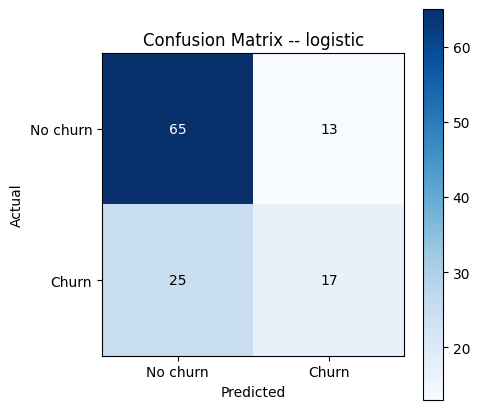

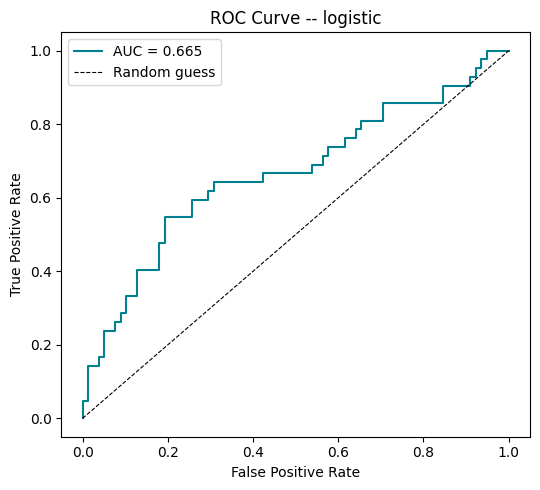

In [7]:
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

fig1 = plot_confusion_matrix(y_test, y_pred, labels=["No churn", "Churn"],
                              title=f"Confusion Matrix -- {best_model_name}")
plt.show()

fig2 = plot_roc_curve(y_test, y_proba, title=f"ROC Curve -- {best_model_name}")
plt.show()

## Feature importance

Logistic Regression doesn't expose `.feature_importances_` (that's a tree-model-only
attribute), so we use permutation importance instead -- it works for any model type.

In [8]:
from src.evaluation.importance import permutation_feature_importance

feature_names = get_feature_names(best_pipeline)
print(f"{len(feature_names)} features after preprocessing: {feature_names}")

X_test_processed = best_pipeline.named_steps["preprocessor"].transform(X_test)
importance_df = permutation_feature_importance(
    best_pipeline.named_steps["model"], X_test_processed, y_test,
    feature_names=feature_names, n_repeats=15, scoring="roc_auc",
)
importance_df

12 features after preprocessing: ['age', 'income', 'monthly_spend', 'support_calls', 'contract_type_Month-to-month', 'contract_type_One year', 'contract_type_Two year', 'city_Bengaluru', 'city_Chennai', 'city_Delhi', 'city_Mumbai', 'city_Pune']


,feature,importance_mean,importance_std
0,support_calls,0.059361,0.034446
1,contract_type_Month-to-month,0.033089,0.014649
2,income,0.028755,0.015445
3,monthly_spend,0.026048,0.025465
4,contract_type_Two year,0.009503,0.007922
5,contract_type_One year,0.002259,0.001897
6,city_Pune,0.001445,0.002765
7,city_Chennai,0.000590,0.000645
8,city_Mumbai,0.000285,0.000324
9,city_Bengaluru,-0.000183,0.003894


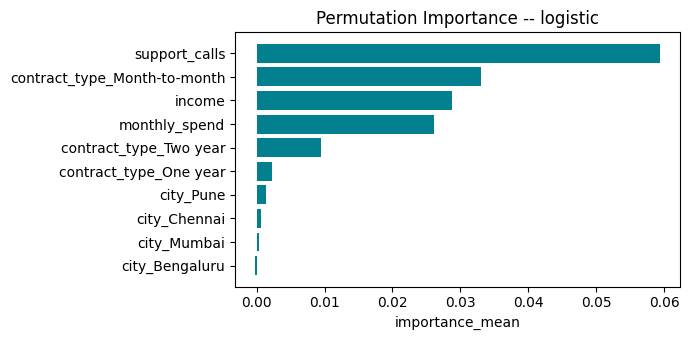

In [9]:
fig3 = plot_feature_importance(importance_df, top_n=10, title=f"Permutation Importance -- {best_model_name}")
plt.show()

## Summary

`compare_models()` shortlisted the best classifier, `tune_model()` picked its best
hyperparameters with a model-appropriate grid, and `evaluate_model()` + the visualization
helpers produced the standard reporting plots — all without writing custom
preprocessing or metric code.